<a href="https://colab.research.google.com/github/faith-dev122/BIT4133-NLP-Project/blob/main/Week_8_Practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# WEEK 8: Transformer Models and Attention Mechanisms
# Installing Hugging Face Transformers library
!pip install transformers torch --quiet

import transformers
import torch
print("Transformers version:", transformers.__version__)
print("PyTorch version    :", torch.__version__)
print("All libraries ready for Transformer tasks!")

Transformers version: 5.12.0
PyTorch version    : 2.11.0+cpu
All libraries ready for Transformer tasks!


In [ ]:
# WEEK 8 Practical Task 1: Sentiment Analysis
# Using a pre-trained BERT-based Transformer model
from transformers import pipeline

# Load the sentiment analysis pipeline
# This downloads a pre-trained DistilBERT model automatically
classifier = pipeline("sentiment-analysis")

print("TRANSFORMER-BASED SENTIMENT ANALYSIS")
print("=" * 60)
print("Model: DistilBERT (distilled version of BERT)")
print("Task : Classify text as POSITIVE or NEGATIVE\n")

# Required: one positive, one negative, one neutral
test_texts = [
    # Positive review
    "I enjoyed learning Natural Language Processing. The concepts are fascinating and well explained.",
    # Negative review
    "This was a terrible experience. The service was awful and I wasted my entire day.",
    # Neutral statement
    "The lecture started at 8am and ended at 11am. There were twenty students present.",
    # Kenyan context examples
    "Safaricom M-Pesa makes sending money incredibly easy and convenient.",
    "The matatu was delayed for two hours and the driver was very rude.",
    "I went to the supermarket and bought groceries for the week.",
]

labels = [
    "Positive review",
    "Negative review",
    "Neutral statement",
    "Kenyan context — Positive",
    "Kenyan context — Negative",
    "Kenyan context — Neutral",
]

print(f"{'Label':<30} {'Result':<12} {'Confidence'}")
print("-" * 60)

for text, label in zip(test_texts, labels):
    result = classifier(text)[0]
    sentiment  = result['label']
    confidence = result['score'] * 100
    flag = "😊" if sentiment == "POSITIVE" else "😞"
    print(f"{label:<30} {flag} {sentiment:<10} {confidence:.2f}%")

print("\nFULL OUTPUT WITH TEXT:")
print("=" * 60)
for text, label in zip(test_texts, labels):
    result = classifier(text)[0]
    print(f"\n[{label}]")
    print(f"  Text      : {text[:80]}...")
    print(f"  Sentiment : {result['label']}")
    print(f"  Confidence: {result['score']*100:.2f}%")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

TRANSFORMER-BASED SENTIMENT ANALYSIS
Model: DistilBERT (distilled version of BERT)
Task : Classify text as POSITIVE or NEGATIVE

Label                          Result       Confidence
------------------------------------------------------------
Positive review                😊 POSITIVE   99.99%
Negative review                😞 NEGATIVE   99.98%
Neutral statement              😊 POSITIVE   98.05%
Kenyan context — Positive      😊 POSITIVE   98.26%
Kenyan context — Negative      😞 NEGATIVE   99.94%
Kenyan context — Neutral       😞 NEGATIVE   99.21%

FULL OUTPUT WITH TEXT:

[Positive review]
  Text      : I enjoyed learning Natural Language Processing. The concepts are fascinating and...
  Sentiment : POSITIVE
  Confidence: 99.99%

[Negative review]
  Text      : This was a terrible experience. The service was awful and I wasted my entire day...
  Sentiment : NEGATIVE
  Confidence: 99.98%

[Neutral statement]
  Text      : The lecture started at 8am and ended at 11am. There were twenty stud

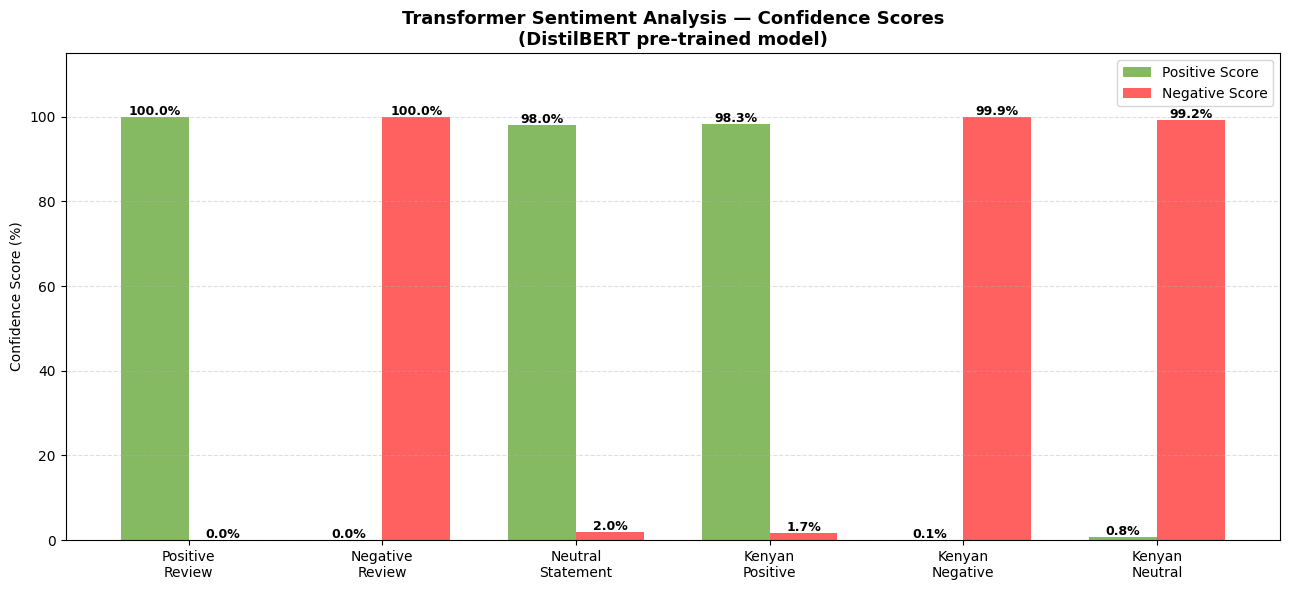

Chart saved.


In [ ]:
# WEEK 8 Practical Task 1 continued
# Visualising sentiment confidence scores
import matplotlib.pyplot as plt
import numpy as np

short_labels = [
    "Positive\nReview",
    "Negative\nReview",
    "Neutral\nStatement",
    "Kenyan\nPositive",
    "Kenyan\nNegative",
    "Kenyan\nNeutral"
]

results   = [classifier(t)[0] for t in test_texts]
pos_scores = [r['score']*100 if r['label']=='POSITIVE' else (1-r['score'])*100 for r in results]
neg_scores = [100 - s for s in pos_scores]

x     = np.arange(len(short_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, pos_scores, width, label='Positive Score',
               color='#70AD47', alpha=0.85)
bars2 = ax.bar(x + width/2, neg_scores, width, label='Negative Score',
               color='#FF4444', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylabel('Confidence Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Transformer Sentiment Analysis — Confidence Scores\n(DistilBERT pre-trained model)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('transformer_sentiment.png', dpi=150)
plt.show()
print("Chart saved.")

In [ ]:
# WEEK 8 Practical Task 2: Text Generation Using GPT-2
# GPT-2 is a Transformer Decoder model that generates text
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

print("GPT-2 TEXT GENERATION")
print("=" * 60)
print("GPT-2: Generative Pre-trained Transformer 2")
print("Developed by OpenAI — the predecessor to ChatGPT\n")

# Different prompt sentences to compare outputs
prompts = [
    "Artificial Intelligence will",
    "Natural Language Processing is used in",
    "The future of technology in Africa",
    "Machine learning helps students to",
]

for prompt in prompts:
    print(f"PROMPT: '{prompt}'")
    print("-" * 55)
    result = generator(prompt, max_length=60,
                       num_return_sequences=1,
                       pad_token_id=50256)
    generated = result[0]['generated_text']
    print(f"GENERATED: {generated}")
    print()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

GENERATED: Artificial Intelligence will be able to work alongside humans and even robots to answer our questions and help solve problem-solving problems as it is already doing.

The results will be published in the online journal Nature Photonics, which will be published next fall.

Explore further: Researchers predict AI could someday give us answers to our world's most pressing questions

More information: J. M. Kolles, "A New Study Suggests A Computational Approach to the Problem of How to Create Artificial Intelligence," Nature Photonics, doi:10.1038/nphoton.2016.094

PROMPT: 'Natural Language Processing is used in'
-------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GENERATED: Natural Language Processing is used in much of the literature on language processing. It is the most basic and simple way to process, and, as a result, is the most popular and widely used.

We'll talk about the types of processing that we use in our language processing and how we use them. This chapter includes an overview of the most popular methods of processing, and the many techniques that we use to process words from different types of text. It also covers some common techniques that you may find useful.

The first and most common method is the "rehearsing" approach, which takes a piece of text and re-writes it into a new form on the computer. For example, we might create a new word with the "g" in it, and then re-write it to match the word. The word would be in a new form, and then re-write it to match the new word. The second approach is the "rehearsing" of the text. For example, we might create a new word with the "s" in it, and then re-write it into a new form on th

[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GENERATED: The future of technology in Africa is not yet clear.

The world's largest mobile phone operator has announced it is closing its headquarters in the Kenyan capital Yuma.

The company is taking steps to provide more affordable service to customers while it seeks to improve performance and reduce costs.

It introduced a pay-as-you-go system after the government passed legislation to pay consumers as they use their phones.

The move was welcomed by the Kenyan government, which has pledged to give more money to mobile companies, which are already running better than their rivals nationwide.

However, it was not immediately clear who might control the move.

The company said it was not clear how it would manage the move.

It is understood that the majority of mobile phone users in the country currently do not use their phones for business.

Some of them are opting for mobile internet over the old Internet, which is where phones are sent to and from, to make use of their cellphones

In [ ]:
# WEEK 8 Practical Task 2 continued
# Comparing different max_length values
# Shows how output length affects generation quality
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")
prompt = "Natural Language Processing helps computers"

print("EFFECT OF max_length ON TEXT GENERATION")
print("=" * 60)
print(f"Fixed prompt: '{prompt}'\n")

for length in [20, 40, 60, 80]:
    result = generator(prompt, max_length=length,
                       pad_token_id=50256,
                       num_return_sequences=1)
    print(f"max_length={length}:")
    print(f"  {result[0]['generated_text']}")
    print()

print("OBSERVATION:")
print("Short max_length produces incomplete thoughts.")
print("Longer max_length allows the model to develop more")
print("complete and coherent sentences — but can also drift")
print("off-topic. This is a key challenge in text generation.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EFFECT OF max_length ON TEXT GENERATION
Fixed prompt: 'Natural Language Processing helps computers'



[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


max_length=20:
  Natural Language Processing helps computers learn to read human voices.

But that's not all. The software also allows for a wide range of different levels of complexity for applications that use the voice recognition technology.

For example, the software allows a human to read a computer's speech for a few seconds. If the human is unable to hear the speech, the software can't tell the computer what it's trying to say.

The software can also be used to learn how to use a computer's voice recognition software to learn information about speech patterns.

The software was developed by a team at the University of Rochester. It will be presented at the IEEE International Conference on Artificial Intelligence.

The software was developed by the U.S. National Institute of Allergy and Infectious Diseases and was developed by The University of Rochester. The results are available online at: http://www.nis.edu/~pierno/

The research was funded by the National Science Foundation,

[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


max_length=40:
  Natural Language Processing helps computers learn more about the world around us. It helps them understand the world around them and why. You can learn more about the world around you by following these easy steps:

1) Download the free Adobe Acrobat Reader for your computer.

2) Download the free Adobe Acrobat Reader and put it on your desktop.

3) Copy the code below into the file system of your computer.


Code:

Copy the code below into the file system of your computer.

4) Open the document, in any language, and type in your computer's language.

5) Type the code in the document you want to learn.

6) Click OK.

7) When you are ready to learn the code, click Next.

8) Once you are ready to learn the code, click Next.

9) You are ready to read the code.

10) Once you are ready to read the code, click Next.

11) Click Next.

12) After you read the code, click Next.

13) Click Next.

14) Click Next.


A note on the above instructions: If you want to learn about langu

[transformers] Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


max_length=60:
  Natural Language Processing helps computers understand the meaning of words and sentences.

How did you get involved with the field of linguistics?

I started writing this book when my father died. He was a hard worker, a good teacher, a good friend of mine. He was a good friend of mine, and he helped me to get to this point. I was very good at it. I worked as an assistant professor in the school of linguistics.

How did you get your first job?

I was going to graduate from the University of California at Berkeley (1974). I was working as a teaching assistant. I had to get a job in the field of linguistics. I had been teaching for about five years before that. I began writing after my father passed.

How did you meet the scientists at the University of California at Berkeley?

They had just published a paper in a journal called The Journal of Language and Language Processing. I was working on a paper for the Journal of Language and Language Processing, which said that 